# 🏠 House Prices EDA

Exploratory Data Analysis of the Ames Housing dataset from Kaggle.

**Goal:** Understand what factors influence house prices the most.

**Dataset:** 1460 houses, 81 features including size, quality, location and sale price.

---

## 📦 Imports

This project uses the core Python libraries for data analysis and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---

## 📥 Data Loading

In [2]:
# Load the dataset from csv file into a pandas DataFrame
df = pd.read_csv('../data/train.csv')

---

## 🔍 Initial Exploration

In [3]:
# Preview the first 5 rows of data
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Check number of rows and columns
df.shape

(1460, 81)

In [5]:
# Check data types and non-null counts for each column.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

Analyzing data from `df.info()` you can mention that there are some columns that contain a lot of missing values. For example: `PoolQC`, `MiscFeature` and `Alley`.

---

## 🕳️ 3. Missing Values

On the graphic below you can mention that some columns are missing 90% of data. 

In [6]:
# Check the amount of missing values of each column
missing = df.isnull().sum()

# Filter and sort columns by missing value count
missing = missing[missing > 0].sort_values(ascending=False)

# Result
missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

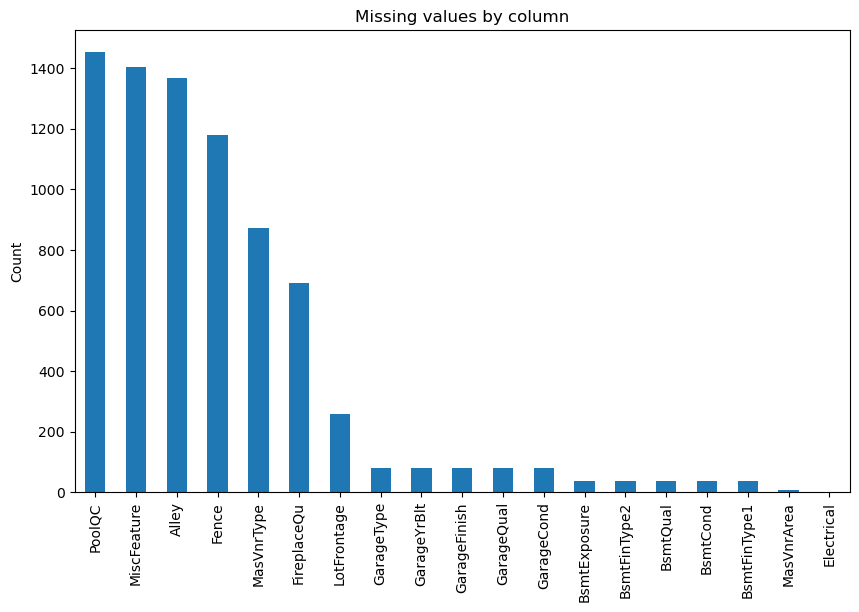

In [7]:
# Visualize missing values per column
plt.figure(figsize=(10, 6))

missing.plot(kind='bar')

plt.title('Missing values by column')
plt.ylabel('Count')

plt.show()

---

## 💰 4. Price Distribution

From the statistical metrics we can see that the mean (181k) is higher than the median (163k), which indicates that a few expensive houses are skewing the average upward. Additionally, there is a big difference between the cheapest (35k) and the most expensive (755k) houses. Most houses are between 100k and 220k (you can see it on the distribution visualization) and it is 75% of all houses.

In [8]:
# Get essential statistical metrics for SalePrice
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

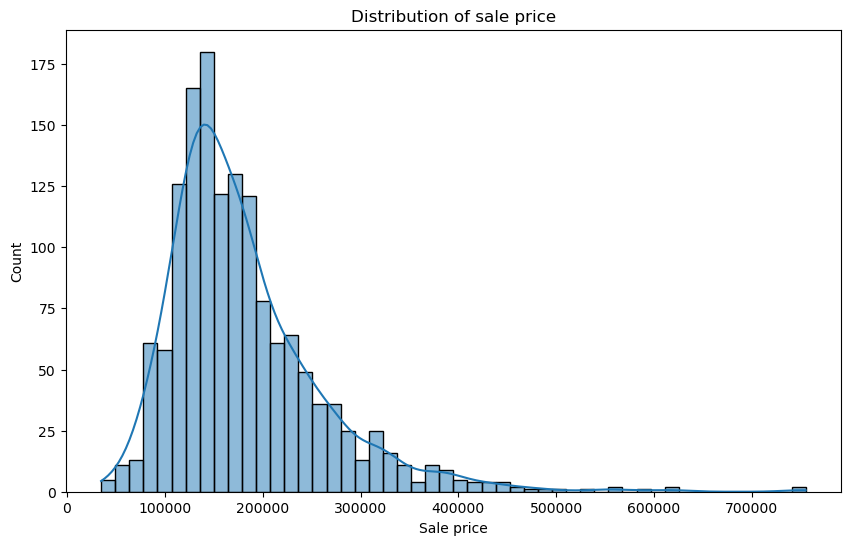

In [9]:
# Visualize distribution of sale price
plt.figure(figsize=(10, 6))

sns.histplot(df['SalePrice'], bins=50, kde=True)

plt.title('Distribution of sale price')
plt.xlabel('Sale price')
plt.ylabel('Count')

plt.show()

---

## 📐 5. Area vs Price

There are two interesting outliers in the area vs price scatter plot. Those houses are more than 4,500 sqft but cost only ~180k. These look like incorrect data entries, since a house of that size with quality rating 10 would typically cost much more.

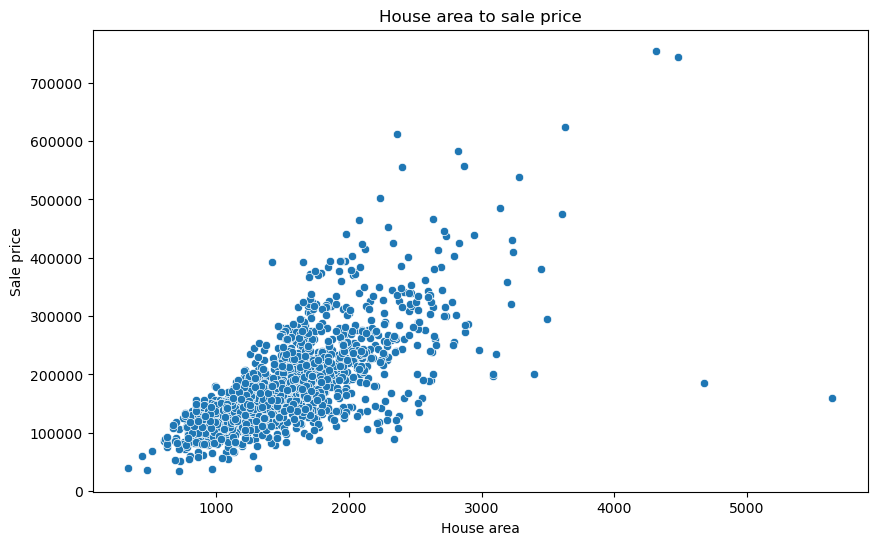

In [10]:
# Visualize the relationship between house area and sale price
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='GrLivArea', y='SalePrice')

plt.title('House area to sale price')
plt.xlabel('House area')
plt.ylabel('Sale price')

plt.show()

In [11]:
# Get more information about those two houses
df[df['GrLivArea'] > 4500][['GrLivArea', 'SalePrice', 'Neighborhood', 'OverallQual']]

,GrLivArea,SalePrice,Neighborhood,OverallQual
523,4676,184750,Edwards,10
1298,5642,160000,Edwards,10


---

## ⭐ 6. Quality vs Price

As you can see in the visualization below, as quality grows, the house price increases. Moreover, the most expensive houses have a bigger difference in prices. For quality levels from 7 to 10 it is difficult to predict the price because the price range is huge.

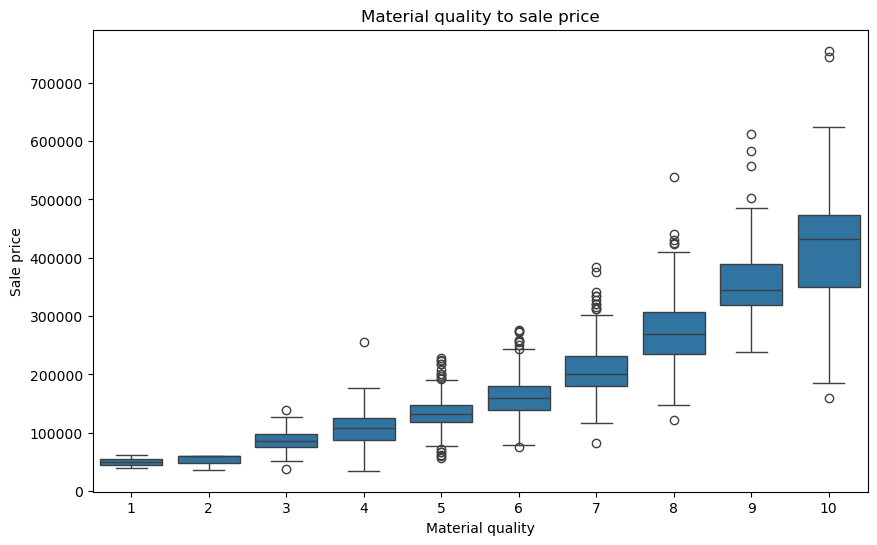

In [12]:
# Visualize price distribution across different quality levels
plt.figure(figsize=(10, 6))

sns.boxplot(x=df['OverallQual'], y=df['SalePrice'])

plt.title('Material quality to sale price')
plt.xlabel('Material quality')
plt.ylabel('Sale price')

plt.show()

---

## 🔗 7. Correlation Analysis

To understand what features influence the price the most, let's plot a heatmap with all available features. However, as you can see, it is not convenient enough to read because of the large number of features. So let's build another heatmap with only the top 10 highest correlations.

On the second visualization we can clearly see a strong correlation between sale price and material quality, sale price and area, and sale price and garage size. Additionally, there is an interesting finding about garage area and garage capacity — they carry the same information, since as garage area grows, the number of cars also grows. That is why their correlation is so high (0.88).

In [13]:
# Select only numerical columns
numeric_df = df.select_dtypes(include='number')

# Find the correlation between colums
corr = numeric_df.corr()

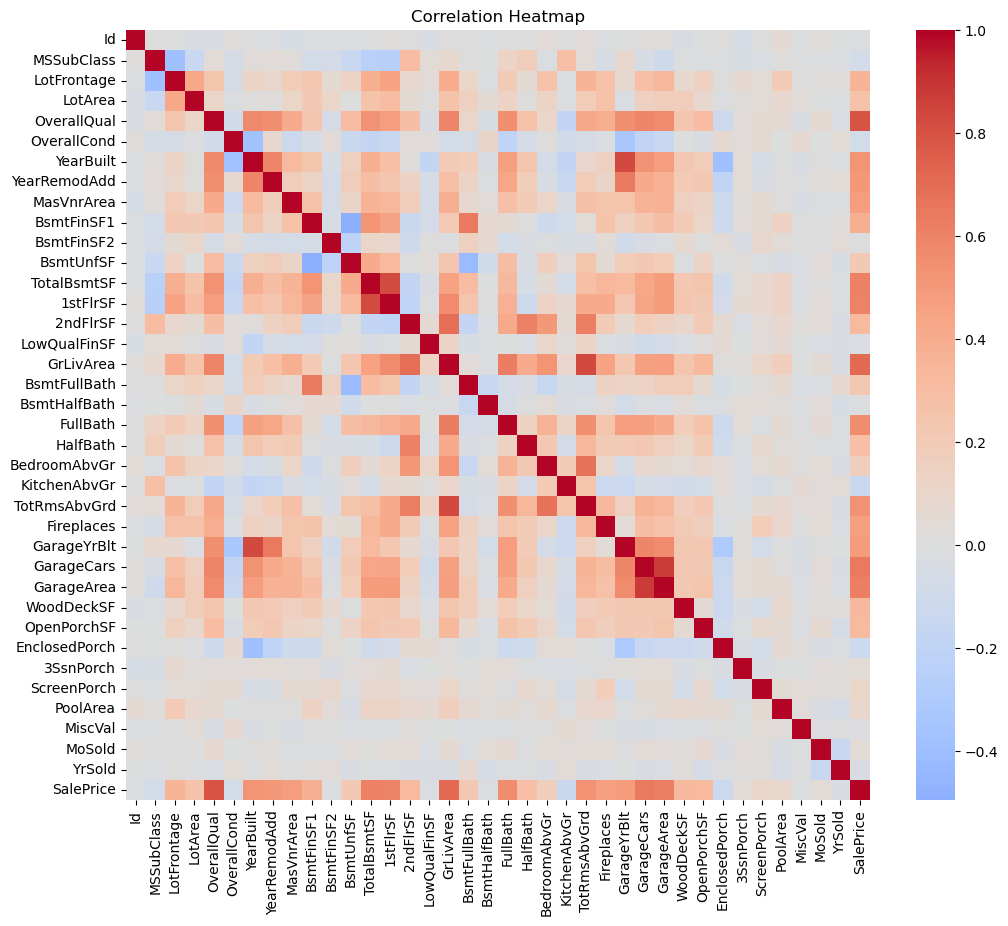

In [14]:
# Visualize the correlation between all numerical columns
plt.figure(figsize=(12, 10))

sns.heatmap(corr, cmap='coolwarm', center=0)

plt.title('Correlation Heatmap')

plt.show()

In [15]:
# Get only the first 10 correlated columns
top_corr = corr['SalePrice'].sort_values(ascending=False).head(10)
top_corr

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

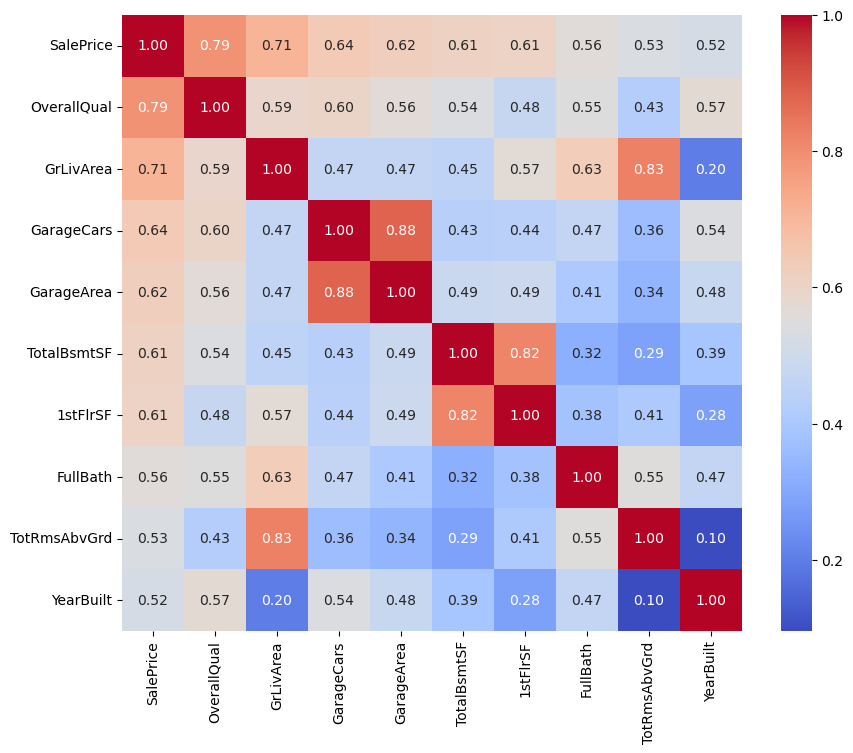

In [16]:
# Get titles of the first 10 correlated columns
top_cols = top_corr.index.tolist()

# Visualize correlation between them
plt.figure(figsize=(10, 8))

sns.heatmap(df[top_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')

plt.show()

---

## 📝 8. Conclusions

In this project we performed an exploratory data analysis of the Ames Housing dataset.

The distribution has shown that most houses are between 130k and 220k which is 75% of all houses. The most influential factor on house sale price is material quality (0.79). The second feature that also has an impact on house sale price is living area (0.71). This dataset contains many missing values and some outliers, so before model training it should be cleaned. Two outliers were found — houses with more than 4,500 sqft but unusually low prices (~180k). Additionally, some features like `GarageCars` and `GarageArea` carry the same information (correlation 0.88) and one of them can be dropped to avoid multicollinearity.